In [174]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [175]:
%pip install numpy
%pip install pandas
%pip install pytest
%pip install jinja2

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrad

### Solar Micro-Grid Dispatch Planner

In [176]:
from src.microgrid import MicroGrid

micro_grid = MicroGrid()
determinant = micro_grid.determinant()
condition = micro_grid.condition()

print(f"Determinant is: {determinant}", f"Condition: {condition}")

Determinant is: -4.999999999999999 Condition: 5.82842712474619


### Explain determinant and condition
**Determinant being -4.99999 or 5.** This means the co-efficients are meaningful and this usable to solve the system, if it was 0, it would be the system's equation are not solveable  
**Condtion being 5.8284...** A condition number of about 5.8284 means a 1% error in D1 or D2 can cause at most about a 5.8284% error in the values of x or y. That's small, so the system is well-conditioned. A large condition number , say more that 100, in 1000s or more, would cause significant measurement errors

### Interactive Input

In [177]:
from src.validate import Validate

try:
    validate = Validate()
    
    d1_interactive = input('Provide daytime load (KWh): ')
    validate.check_energy_input(d1_interactive)

    d2_interactive = input('Provide critical-equipment load (kWh):')
    validate.check_energy_input(d2_interactive)
    
    #solve
    result = micro_grid.solve_day(float(d1_interactive),float(d2_interactive))
    
    print("Results: ",result)
except Exception as e:
    print(e)    



Results:  [ 1.6 -0.4]


### Generate CSV file


In [178]:
from src.csv_generator import CsvGenerator
from pathlib import Path
import csv

csv_file_path = './files/solar_data.csv'
csv_generator = CsvGenerator()

#generate file
csv_generator.solar_grid_csv(csv_file_path,30,36)

#check if csv file exists
if Path(csv_file_path).exists():
    print(f"File {csv_file_path} generate successfully!")


File ./files/solar_data.csv generate successfully!


### Read csv file and solve for all 30 days

**Benchmarking, solve in Loop vs single vectorized cell**

In [179]:
import pandas
import timeit
import numpy
import jinja2

def solve_with_loop(d_data):
    results = []
    #processing with loop
    for l_d1, l_d2 in d_data:
        results.append(micro_grid.solve_day(l_d1, l_d2))
    return results            

def solve_with_single_v_cell(d_data):
    #solve with single vectorized cell
    return numpy.linalg.solve(micro_grid.co_efficients, d_data.T).T
     

#only run bench marking n_runs number of times
n_runs = 5000

# check if file exists
if Path(csv_file_path).exists():
    with open(csv_file_path, "r") as file:
        rows = list(csv.DictReader(file))
        d_data = numpy.array([[float(r["d1"]), float(r["d2"])] for r in rows])
            
    #solve with loop
    time_taken_loop = timeit.timeit(lambda: solve_with_loop(d_data), number = n_runs)
    
    #solve with single vectorized cell
    time_taken_single_v_cell = timeit.timeit(lambda: solve_with_single_v_cell(d_data),  number = n_runs)
    
    #bench mark results
    benchmark = pandas.DataFrame({
                    "method": ["loop", "vectorized"],
                    "Avg time (ms) per run": [(time_taken_loop * 1e3)/n_runs, (time_taken_single_v_cell * 1e3)/n_runs], #need to get time per run
                    "Avg speed-up": [1.0, time_taken_loop / time_taken_single_v_cell],
                })      
     
    display(benchmark.set_index("method").round(3).style.set_caption(f"Benchmark over {n_runs:,} runs")
    )


    # df = pandas.DataFrame(results,columns=["day", "d1", "d2", "x", "y"])
    # df

else:
     print(f"{csv_file_path} does not exist!")    

,Avg time (ms) per run,Avg speed-up
method,,
loop,0.204000,1.000000
vectorized,0.006000,34.039000


**The vectorized processing is almost 30-times faster than using loop**

### Detect and dlag infeasible days
*** Generate some bad data and use that**

In [180]:
from scipy.optimize import nnls

#generate bad data
bad_csv_file_path = './files/solar_bad_data.csv'
csv_generator_2 = CsvGenerator()
csv_generator_2.solar_grid_csv(bad_csv_file_path, 30, 36, False)

#check if csv file with bad data exists
if Path(bad_csv_file_path).exists():
    with open(bad_csv_file_path, "r") as file:
        bad_data_rows = list(csv.DictReader(file))

    report = []
    for r in bad_data_rows:
        day, d1, d2 = int(r["day"]), float(r["d1"]), float(r["d2"])

        #negative demand is bad data, nothing to solve
        if d1 < 0 or d2 < 0:
            report.append([day, d1, d2, None, None, None, None, None, None, None, None, "invalid input"])
            continue

        x, y = micro_grid.solve_day(d1, d2)

        if x >= -1e-9 and y >= -1e-9:
            #feasible: exact solution, no gap, no error
            fx, fy, status = x, y, "ok"
            nnls_error, clip_error = 0.0, 0.0
        else:
            #option 1, clipping: set negative values to 0, keep the other as is
            cx, cy = max(x, 0), max(y, 0)
            clip_error = ((3*cx + 2*cy - d1)**2 + (4*cx + cy - d2)**2) ** 0.5

            #option 2, nnls: best non-negative x, y (used as the dispatch)
            (fx, fy), nnls_error = nnls(micro_grid.co_efficients, [d1, d2])
            status = "infeasible (nnls)"

        #gap = supplied minus demanded, negative means a shortfall
        d1_gap = 3*fx + 2*fy - d1
        d2_gap = 4*fx + fy - d2

        report.append([day, d1, d2, x, y, fx, fy, d1_gap, d2_gap, clip_error, nnls_error, status])

    report = pandas.DataFrame(report, columns=[
        "day", "d1", "d2", "x_exact", "y_exact", "x", "y",
        "d1_gap", "d2_gap", "clip_error", "nnls_error", "status"
    ]).set_index("day")

    print(report["status"].value_counts())
    display(report[report["status"] != "ok"].round(3))
else:
    print(f"{bad_csv_file_path} does not exist!")

status
ok                   24
invalid input         3
infeasible (nnls)     3
Name: count, dtype: int64


,d1,d2,x_exact,y_exact,x,y,d1_gap,d2_gap,clip_error,nnls_error,status
day,,,,,,,,,,,
5,-94.95,73.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,invalid input
10,107.79,161.68,43.114,-10.776,38.804,0.000,8.621,-6.466,24.096,10.776,infeasible (nnls)
15,93.37,-71.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,invalid input
20,88.59,35.43,-3.546,49.614,5.910,25.974,-18.912,14.184,17.730,0.000,infeasible (nnls)
25,-94.70,65.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,invalid input
30,93.40,140.10,37.360,-9.340,33.624,0.000,7.472,-5.604,20.885,9.340,infeasible (nnls)


### Statistics for mean, variance and standard deviation

In [181]:
import statistics

#use good data
with open (csv_file_path,'r') as file:
    good_data_rows = list(csv.DictReader(file))
    
solar, battery = list(), list()
for data in good_data_rows:
    x,y = micro_grid.solve_day(float(data['d1']), float(data['d2']))
    solar.append(float(x))
    battery.append(float(y))

s_mean = statistics.mean(solar)
s_std = statistics.stdev(solar)
s_var = statistics.variance(solar)

b_mean = statistics.mean(battery)
b_std = statistics.stdev(battery)
b_var = statistics.variance(battery)

stats = pandas.DataFrame({
    'solar -> x':{
        "mean kWh":s_mean,
        "variance kWh²":s_var,
        "standard deviation kWh":s_std,
        "co-efficient of variation":s_std/s_mean
    },
    'battery -> y':{
        "mean kWh":b_mean,
        "variance kWh²":b_var,
        "standard deviation kWh":b_std,
        "co-efficient of variation":b_std/b_mean
    }                  

})

display(stats.round(3).style.set_caption(f"Energy usage over {len(rows)} days"))    

,solar -> x,battery -> y
mean kWh,7.598000,35.669000
variance kWh²,6.896000,29.745000
standard deviation kWh,2.626000,5.454000
co-efficient of variation,0.346000,0.153000


**Conclusion**
From the data, the battery's standard deviation is almost twice that of solar, so it seems more volatile in daily use. 
Overall, however, solar is more volatile when we look at the coefficient of variation.
This is because the battery supplies most of the energy, so its variations are larger in kWh but small relative to its average, while solar supplies much less, so similar-sized changes are a much bigger share of its output.

### Cost model

In [182]:
s_price = 150      
b_price = 450 

#use good data
with open(csv_file_path, "r") as file:
    rows = list(csv.DictReader(file))

daily = []
for r in rows:
    x, y= micro_grid.solve_day(float(r["d1"]),  float(r["d2"]))
    daily.append([int(r["day"]), x , y, s_price *x, b_price * y])

costs = pandas.DataFrame(daily,  columns=["day", "solar_kwh", "battery_kwh", "solar_cost", "battery_cost"]).set_index("day")
costs["total_cost"] =costs[ "solar_cost"] + costs["battery_cost"]

#daily costs
display( costs.round(2).style.set_caption("Daily energy cost (UGX)"))

#monthly summary
monthly =pandas.DataFrame({
    "kWh": [costs["solar_kwh"].sum(), costs["battery_kwh"].sum(), costs["solar_kwh"].sum() + costs["battery_kwh"].sum()],
    "cost (UGX)": [costs["solar_cost"].sum(), costs["battery_cost"].sum(), costs["total_cost"].sum()],
}, index=["solar", "battery", "total"])
monthly["share of cost"] = monthly["cost (UGX)"] / costs["total_cost"].sum()

display(monthly.round(3).style.set_caption( f"Monthly energy cost over {len(costs)} days (UGX)"))
print(f"Average daily cost: UGX {costs['total_cost' ].mean():,.0f}")

,solar_kwh,battery_kwh,solar_cost,battery_cost,total_cost
day,,,,,
1,11.390000,31.200000,1708.500000,14040.000000,15748.500000
2,8.510000,41.830000,1276.200000,18822.600000,20098.800000
3,8.940000,39.490000,1341.000000,17770.500000,19111.500000
4,10.710000,28.940000,1606.500000,13023.000000,14629.500000
5,10.300000,32.020000,1545.300000,14409.900000,15955.200000
6,4.610000,32.420000,690.900000,14587.200000,15278.100000
7,4.260000,34.050000,638.400000,15320.700000,15959.100000
8,9.390000,39.200000,1407.900000,17638.200000,19046.100000
9,10.330000,32.950000,1550.100000,14829.300000,16379.400000


,kWh,cost (UGX),share of cost
solar,227.926000,34188.900000,0.066000
battery,1070.076000,481534.200000,0.934000
total,1298.002000,515723.100000,1.000000


Average daily cost: UGX 17,191


***conclusion**
The battery supplies most of the clinic's energy and, because it costs far more per kWh than solar, it makes up almost the entire energy bill. Solar is the cheap source, but it covers only a small share of each day's demand. In this model, the daily loads fix how much each source must supply, so the clinic cannot save money by simply drawing more from solar. Lowering the bill would need a change to the system itself, such as adding panels so that solar can carry more of the load

### Plot daily solar vs battery usage

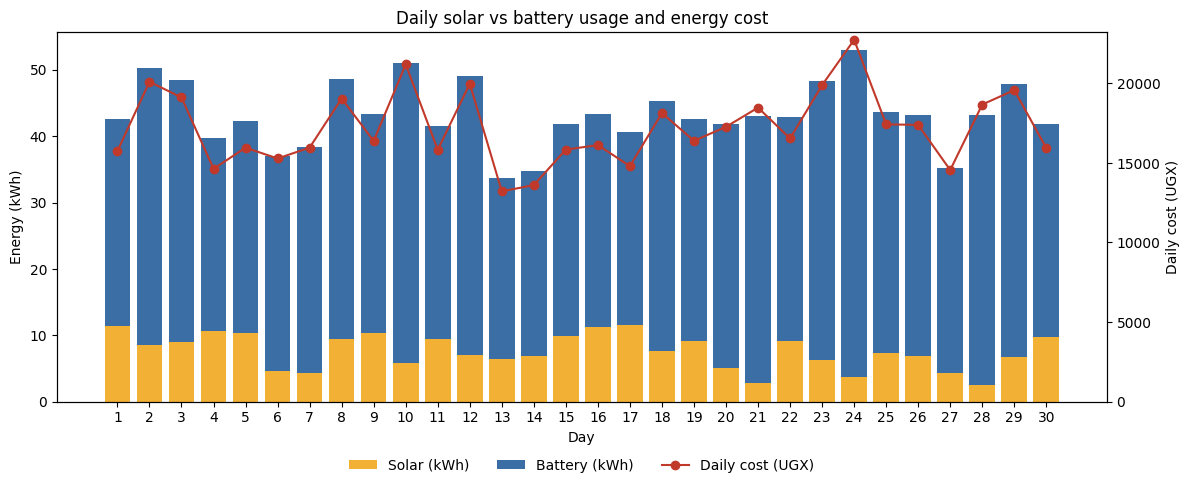

In [183]:
import matplotlib.pyplot as plt

fig, ax_energy = plt.subplots(figsize=(12, 5))

#stacked bars: solar at the bottom, battery on top
ax_energy.bar(costs.index, costs["solar_kwh"], label="Solar (kWh)", color="#f2b134")
ax_energy.bar(costs.index, costs["battery_kwh"], bottom=costs["solar_kwh"], label="Battery (kWh)", color="#3a6ea5")
ax_energy.set_xlabel("Day")
ax_energy.set_ylabel("Energy (kWh)")
ax_energy.set_xticks(costs.index)

#second y-axis for cost, sharing the same days
ax_cost = ax_energy.twinx()
ax_cost.plot(costs.index, costs["total_cost"], color="#c0392b", marker="o", label="Daily cost (UGX)")
ax_cost.set_ylabel("Daily cost (UGX)")
ax_cost.set_ylim(bottom=0)

#one legend for both axes, placed below the chart so it doesn't cover the line
bars, bar_labels = ax_energy.get_legend_handles_labels()
line, line_labels = ax_cost.get_legend_handles_labels()
ax_energy.legend(bars + line, bar_labels + line_labels, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)

ax_energy.set_title("Daily solar vs battery usage and energy cost")
fig.tight_layout()
plt.show()

### Extension 1: Hybrid micro-grid with a diesel generator

`HybridMicroGrid` (in `src/hybrid_microgrid.py`) inherits from `MicroGrid`. It adds a diesel generator (z) to both existing loads and a third constraint, a night-time load. Solar produces nothing at night, so x has no term in that equation:

- 3x + 2y + z = D1 (daytime load)
- 4x + y + 2z = D2 (critical-equipment load)
- 2y + 3z = D3 (night-time load)

The diesel coefficients and the night-time equation are my own assumptions. The inherited `determinant()` and `condition()` methods work on the 3×3 matrix unchanged.

In [184]:
from src.hybrid_microgrid import HybridMicroGrid

hybrid_grid = HybridMicroGrid()
print(f"Determinant: {hybrid_grid.determinant():.2f}, condition number: {hybrid_grid.condition():.2f}, rank: {hybrid_grid.rank()}")

#example day: the weekday baseline loads plus a 90 kWh night-time load
x, y, z = hybrid_grid.solve_day(100, 70, 90)
print(f"Solar x = {x:.2f} kWh, battery y = {y:.2f} kWh, diesel z = {z:.2f} kWh")

Determinant: -19.00, condition number: 5.91, rank: 3
Solar x = 5.79 kWh, battery y = 39.47 kWh, diesel z = 3.68 kWh


#### When the third equation depends on the other two

In [185]:
#the night-time row is now the sum of the daytime and critical-equipment rows
dependent_grid = HybridMicroGrid(night_row=[7, 3, 3])
print(f"Rank: {dependent_grid.rank()}, condition number: {dependent_grid.condition():.2e}")

try:
    dependent_grid.solve_day(100, 70, 170)
except ValueError as e:
    print("solve_day:", e)

#D3 = D1 + D2 follows the same dependence as the rows; any other D3 contradicts it
print("D3 = 170:", dependent_grid.solution_count(100, 70, 170))
print("D3 = 150:", dependent_grid.solution_count(100, 70, 150))

#a row that is almost, but not exactly, the sum of the other two
near_grid = HybridMicroGrid(night_row=[7, 3, 3.01])
print(f"\nNearly dependent row: condition number {near_grid.condition():,.0f}")
print("D3 = 170:       ", near_grid.solve_day(100, 70, 170).round(2))
print("D3 = 170 + 1%:  ", near_grid.solve_day(100, 70, 170 * 1.01).round(2))

Rank: 2, condition number: 2.48e+16
solve_day: Invalid Co-efficient combination!
D3 = 170: infinitely many
D3 = 150: none

Nearly dependent row: condition number 2,146
D3 = 170:        [ 8. 38. -0.]
D3 = 170 + 1%:   [-94. 106. 170.]


**Discussion**

The hybrid system has a determinant of −19 and a condition number of 5.91, close to the two-source system's 5.83, so adding diesel and a night-time load keeps the problem well-posed. On the example day, with loads of 100, 70 and 90 kWh, the battery still does most of the work (39.47 kWh), with 5.79 kWh from solar and 3.68 kWh from diesel.

If the third equation is the sum of the other two, it adds no new information. The rank drops from 3 to 2, the determinant becomes 0, and `solve_day()` rejects the system. What that means depends on D3. If D3 = D1 + D2, the loads follow the same dependence as the equations, and there are infinitely many ways to split them between the three sources. Any other D3 contradicts the first two equations, and no split meets all three loads. Either way, there is no single dispatch plan to follow.

A row that is only nearly dependent is more dangerous, because it still solves. With [7, 3, 3.01] the condition number is 2,146, and a 1% change in D3 moves solar from 8 kWh to −94 kWh. A new constraint is only useful if it measures something the existing loads do not already cover.

### Extension 2: Sensitivity analysis

`SensitivityAnalysis` (in `src/sensitivity.py`) takes the 30-day average demand and makes 1,000 Monte Carlo draws. Each draw multiplies D1 and D2 by independent random factors between 0.95 and 1.05 (±5%), using numpy's seeded generator (`numpy.random.default_rng(42)`), and solves the day again.

The amplification of a draw is the relative change in the dispatch (x and y together) divided by the relative change in the demand. The condition number is the largest value it can ever reach.

In [186]:
from src.sensitivity import SensitivityAnalysis

#average demand over the 30 days in solar_data.csv (d_data comes from the benchmark cell)
avg_d1, avg_d2 = d_data.mean(axis=0)
base_x, base_y = micro_grid.solve_day(avg_d1, avg_d2)

sensitivity = SensitivityAnalysis(micro_grid, n_draws=1000, spread=0.05, seed=42)
demands, dispatch = sensitivity.run(avg_d1, avg_d2)
amplification = sensitivity.amplification(avg_d1, avg_d2)

sensitivity_rows = []
for source, base, values in [("solar -> x", base_x, dispatch[:, 0]), ("battery -> y", base_y, dispatch[:, 1])]:
    change = (values - base) / base * 100
    sensitivity_rows.append({
        "source": source,
        "unperturbed kWh": base,
        "min kWh": values.min(),
        "max kWh": values.max(),
        "std kWh": values.std(),
        "largest change %": numpy.abs(change).max(),
    })

print(f"Average demand: D1 = {avg_d1:.2f} kWh, D2 = {avg_d2:.2f} kWh")
display(pandas.DataFrame(sensitivity_rows).set_index("source").round(2).style.set_caption("Dispatch over 1,000 draws with ±5% demand errors"))
print(f"Largest amplification: {amplification.max():.2f}, average: {amplification.mean():.2f}, condition number: {micro_grid.condition():.2f}")

Average demand: D1 = 94.13 kWh, D2 = 66.06 kWh


,unperturbed kWh,min kWh,max kWh,std kWh,largest change %
source,,,,,
solar -> x,7.600000,5.450000,9.700000,0.920000,28.290000
battery -> y,35.670000,30.290000,41.220000,2.450000,15.560000


Largest amplification: 3.40, average: 2.25, condition number: 5.83


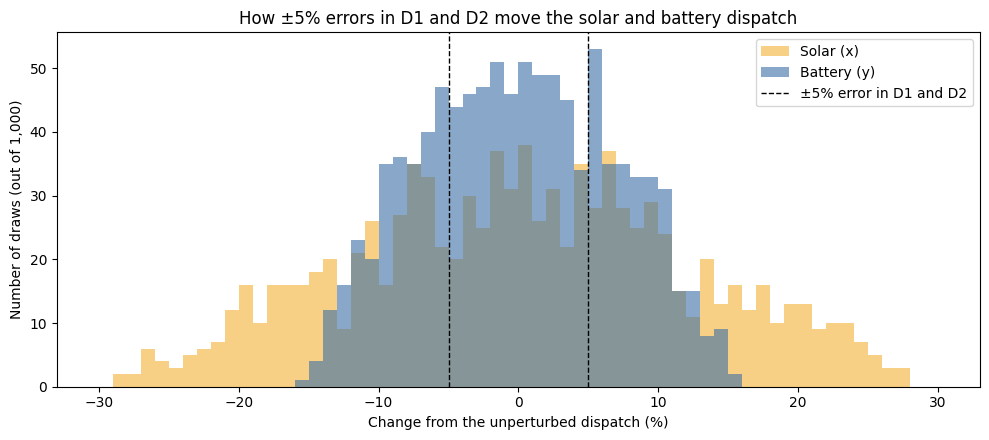

In [187]:
fig, ax = plt.subplots(figsize=(10, 4.5))

#percentage change from the unperturbed dispatch, one value per draw
bins = numpy.linspace(-30, 30, 61)
ax.hist((dispatch[:, 0] - base_x) / base_x * 100, bins=bins, alpha=0.6, color="#f2b134", label="Solar (x)")
ax.hist((dispatch[:, 1] - base_y) / base_y * 100, bins=bins, alpha=0.6, color="#3a6ea5", label="Battery (y)")
ax.axvline(-5, color="black", linestyle="--", linewidth=1, label="±5% error in D1 and D2")
ax.axvline(5, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Change from the unperturbed dispatch (%)")
ax.set_ylabel("Number of draws (out of 1,000)")
ax.set_title("How ±5% errors in D1 and D2 move the solar and battery dispatch")
ax.legend()
fig.tight_layout()
plt.show()

**Discussion**

At the 30-day average demand (D1 = 94.13 kWh, D2 = 66.06 kWh), the unperturbed dispatch is 7.60 kWh of solar and 35.67 kWh of battery. Across the 1,000 draws, solar ranges from 5.45 to 9.70 kWh, up to 28% away from its unperturbed value, and battery from 30.29 to 41.22 kWh, up to 16% away. Both move further than the 5% error in the readings, as the histogram shows.

The condition number of 5.83 sets the limit on this. Whatever the error, the relative change in the dispatch as a whole can be at most 5.83 times the relative error in the demands. The largest amplification in the 1,000 draws was 3.40, and the average 2.25, so every draw stays inside that limit. The limit is only reached for the worst possible combination of demand and error direction, which draws around one average day do not hit. With the nearly dependent row from Extension 1 (condition number 2,146), the same limit would be hundreds of times higher.

The condition number bounds the dispatch as a whole, not each source. Solar moves the most because x = (2D2 − D1) / 5 is a small difference between two large loads, so a small error in either load is a large share of x. The largest changes come when D1 and D2 are wrong in opposite directions. If both readings are 5% high, x and y are simply 5% higher. For planning, the solar figure is the least reliable: with ±5% meter errors it could be off by more than a quarter.